# Прогнозирование систолического артериального давления в NHANES

**Автор: Egor Fedosov.** Задача - воспроизводимый пайплайн регрессии для SystolicBloodPressureMmHg (мм рт. ст.) из NHANES. Сначала проверяю качество данных и удаляю точные повторы участников, затем отделяю тест, провожу EDA на обучающей части и выбираю модель по train-only CV.

Ноутбук рассчитан на последовательный запуск сверху вниз. Зависимости с зафиксированными версиями находятся в requirements.txt.

## 1. Импорт, настройки и чтение данных

Фиксированный RANDOM_STATE делает разбиение, кросс-валидацию и обученную модель повторяемыми. Путь определяется относительно текущей рабочей директории: ноутбук можно запускать как из папки ML, так и из корня репозитория.

In [1]:
from pathlib import Path
import os
import platform

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')

project_dir = Path.cwd()
if not (project_dir / 'data' / 'nhanes.csv').exists():
    project_dir = project_dir / 'ML'
data_dir = project_dir / 'data'
assert (data_dir / 'nhanes.csv').exists(), f'CSV was not found in {data_dir.resolve()}'

df = pd.read_csv(data_dir / 'nhanes.csv', low_memory=False)
metadata = pd.read_csv(data_dir / 'nhanes_metadata.csv')

print(f'Python: {platform.python_version()} | pandas: {pd.__version__} | scikit-learn: {sklearn.__version__}')
print(f'Data shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print('Initial data preview is deferred until after the train/test split.')

Matplotlib is building the font cache; this may take a moment.


Python: 3.13.12 | pandas: 2.3.3 | scikit-learn: 1.9.0
Data shape: 8,533 rows x 194 columns
Initial data preview is deferred until after the train/test split.


## 2. Аудит данных и целевой переменной

В CSV 8533 строки и 194 столбца, включая SEQN. Найдены 167 точных повторов строк. Удаляю только полные дубли, после чего требую уникальность SEQN: конфликтующие записи одного участника нельзя молча удалять. Это предотвращает попадание одного человека в обучение и тест. Строки без цели исключаю из supervised-анализа. По метаданным цель - среднее доступных повторных измерений давления.

Правила очистки заданы смыслом переменных, без подбора по метрикам: для MinutesSedentaryActivity (PAD680) коды 7777/9999 и значения вне [0, 1440) заменяю на NaN. По [официальному CDC codebook](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/PAQ_J.htm#PAD680) это отказ/неизвестный ответ, а не минуты. Значения с абсолютной величиной меньше 1e-12 округляю до нуля как значения ниже точности целых минут; это явное численное допущение, а не установленная причина появления артефакта. Уже перекодированные YesNo сохраняю как 0/1, Borderline в вопросе о диабете - отдельная категория.

Затем отделяю 20% уникальных участников с seed=42 и стратификацией по децилям цели. Все дальнейшие EDA и статистики предобработки используют только train.

In [2]:
TARGET = 'SystolicBloodPressureMmHg'

raw_rows = len(df)
raw_supervised = int(df[TARGET].notna().sum())
df = df.drop_duplicates().copy()
assert df['SEQN'].notna().all() and df['SEQN'].is_unique, 'Conflicting participant records need a grouped analysis.'
df = df.set_index('SEQN', verify_integrity=True)
print('Exact duplicate rows removed:', raw_rows - len(df))
print('Unique participants:', len(df))
print('Missing target after deduplication:', int(df[TARGET].isna().sum()))
print('Supervised rows after deduplication:', int(df[TARGET].notna().sum()))
print('Duplicate supervised rows removed:', raw_supervised - int(df[TARGET].notna().sum()))
sedentary = df['MinutesSedentaryActivity']
invalid_sedentary = sedentary.isin([7777, 9999]) | (sedentary < 0) | (sedentary >= 1440)
tiny_sedentary = sedentary.notna() & (sedentary != 0) & (sedentary.abs() < 1e-12)
print('PAD680 invalid/special codes -> NaN:', int(invalid_sedentary.sum()))
print('PAD680 near-zero values -> 0:', int(tiny_sedentary.sum()))
df.loc[invalid_sedentary, 'MinutesSedentaryActivity'] = np.nan
df.loc[tiny_sedentary, 'MinutesSedentaryActivity'] = 0.0
supervised = df.loc[df[TARGET].notna()].copy()
strata = pd.qcut(supervised[TARGET], q=10, duplicates='drop')
train_df, test_df = train_test_split(supervised, test_size=0.20, random_state=RANDOM_STATE, stratify=strata)
assert train_df.index.intersection(test_df.index).empty
assert train_df.index.is_unique and test_df.index.is_unique
print(f'Train: {len(train_df):,}; test: {len(test_df):,}; participant overlap: 0')
display(train_df.head(3))

display(metadata.loc[metadata['VariableNameLong'].eq(TARGET), ['VariableNameLong', 'Label', 'EnglishText', 'Source', 'CustomRecoding', 'nNonNA']])
display(train_df[TARGET].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]).to_frame('train mm Hg'))

missing_all = train_df.isna().mean().mul(100).sort_values(ascending=False).rename('train missing_%')
display(Markdown('**Наиболее неполные переменные на train (первые 12):**'))
display(missing_all.head(12).to_frame().round(1))

Exact duplicate rows removed: 167
Unique participants: 8366
Missing target after deduplication: 1652
Supervised rows after deduplication: 6714
Duplicate supervised rows removed: 132
PAD680 invalid/special codes -> NaN: 32
PAD680 near-zero values -> 0: 3
Train: 5,371; test: 1,343; participant overlap: 0


,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,TypeOfMilkFirstFed1Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
SEQN,,,,,,,,,,,,,,,,,,,,,
98988.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,216.0,NaN,Never
95375.0,Excellent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,165.0,0.0,Never
101306.0,Excellent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,VariableNameLong,Label,EnglishText,Source,CustomRecoding,nNonNA
82,SystolicBloodPressureMmHg,"Systolic blood pressure, mm Hg",Systolic blood pressure in millimeters of merc...,BPX,Arithmetic mean of the available readings BPXS...,6714.0


,train mm Hg
count,5371.000000
mean,121.681996
std,20.355784
min,72.666667
1%,88.666667
5%,96.000000
25%,106.666667
50%,118.000000
75%,132.666667
95%,160.000000


**Наиболее неполные переменные на train (первые 12):**

,train missing_%
RecumbentLengthCm,100.0
TypeOfMilkFirstFed2Milk,100.0
60SecHr30SecHr2,100.0
EverBreastfedOrFedBreastmilk,100.0
AgeInMonthsAtScreening0To24Mos,100.0
TypeOfMilkFirstFedOther,100.0
TypeOfMilkFirstFedSoyMilk,100.0
TypeOfMilkFirstFed1Milk,100.0
TypeOfMilkFirstFedFatFreeMilk,100.0
TypeOfMilkFirstFedWholeMilk,100.0


## 3. EDA

EDA проводится только на train и отвечает на три вопроса: как распределена цель, есть ли связь с возрастом и антропометрией, насколько неполны признаки. Проверяю распределение и верхний хвост, связь с возрастом, различия по полу и корреляции числовых переменных. Корреляция не означает причинность. Высокие значения давления не удаляю автоматически: статистический выброс не обязательно является ошибкой. Качество константного прогноза проверяется отдельно по CV.

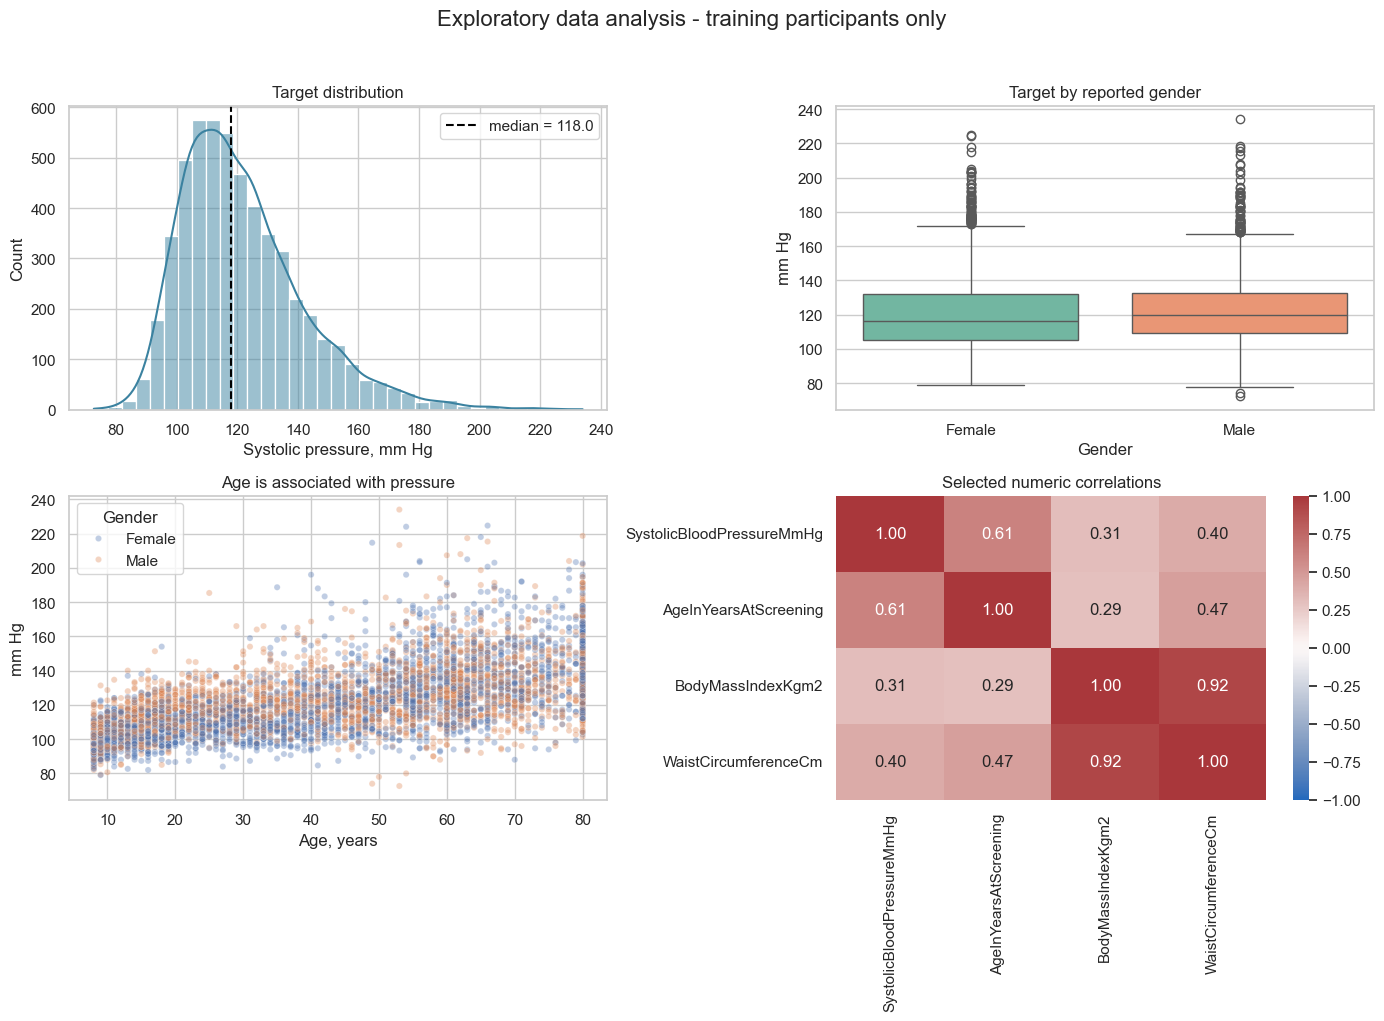

In [3]:
eda = train_df[[TARGET, 'AgeInYearsAtScreening', 'Gender', 'BodyMassIndexKgm2', 'WaistCircumferenceCm']].copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(eda[TARGET], bins=35, kde=True, ax=axes[0, 0], color='#3B82A0')
axes[0, 0].axvline(eda[TARGET].median(), color='black', linestyle='--', label=f'median = {eda[TARGET].median():.1f}')
axes[0, 0].set(title='Target distribution', xlabel='Systolic pressure, mm Hg')
axes[0, 0].legend()

sns.boxplot(data=eda, x='Gender', y=TARGET, hue='Gender', legend=False, palette='Set2', ax=axes[0, 1])
axes[0, 1].set(title='Target by reported gender', xlabel='Gender', ylabel='mm Hg')

sns.scatterplot(data=eda, x='AgeInYearsAtScreening', y=TARGET, hue='Gender', alpha=.35, s=20, ax=axes[1, 0])
axes[1, 0].set(title='Age is associated with pressure', xlabel='Age, years', ylabel='mm Hg')

corr_columns = [TARGET, 'AgeInYearsAtScreening', 'BodyMassIndexKgm2', 'WaistCircumferenceCm']
sns.heatmap(eda[corr_columns].corr(), annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title('Selected numeric correlations')
fig.suptitle('Exploratory data analysis - training participants only', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## 4. Сценарий предсказания и отбор признаков

Моделирую давление участника на скрининговом визите при уже доступных демографических сведениях, антропометрии, анкете и лабораторных показателях. Использую 21 признак из 193 неидентификационных столбцов. Это условный сценарий прогноза при доступности лабораторных результатов, а не прогноз до обследования. Возраст и антропометрия отражают физические характеристики, анамнез и привычки - поведенческий/метаболический контекст, лабораторные показатели - состояние обмена веществ.

SEQN служит только для проверки независимости участников. DiastolicBloodPressureMmHg исключаю: он доступен после той же процедуры измерения давления и несовместим с выбранным сценарием прогноза. Это риск утечки по моменту доступности, а не утверждение, что любой коррелирующий признак является утечкой. Сильно разреженные и узкоспециальные вопросы не использую.

Строки с пропусками в признаках сохраняю. Внутри каждого обучающего фолда числовые пропуски заменяются медианой с индикатором пропуска, категориальные - модой и затем one-hot encoding. Бинарные 0/1 остаются числовыми. Возрастные ограничения анкет могут создавать структурные пропуски у детей; индикаторы частично отражают это, но не устраняют возможное смещение. Фиксированные правила очистки специальных кодов не обучаются на данных, а все оцениваемые статистики находятся в pipeline.

,VariableNameLong,VariableName,Label,Target,CustomRecoding
0,GeneralHealthCondition,HSD010,General health condition,Both males and females 12 YEARS -\n\n\t\t\t15...,NaN
59,SleepHoursWeekdaysOrWorkdays,SLD012,Sleep hours - weekdays or workdays,Both males and females 16 YEARS -\t\t\t150 YEARS,NaN
95,WeightKg,BMXWT,Weight (kg),Both males and females 0 YEARS -\n\n\t\t\t150...,NaN
97,StandingHeightCm,BMXHT,Standing Height (cm),Both males and females 2 YEARS -\n\n\t\t\t150...,NaN
98,BodyMassIndexKgm2,BMXBMI,Body Mass Index (kg/m**2),Both males and females 2 YEARS -\n\n\t\t\t150...,NaN
99,WaistCircumferenceCm,BMXWAIST,Waist Circumference (cm),Both males and females 2 YEARS -\n\n\t\t\t150...,NaN
100,DirectHdlcholesterolMgdl,LBDHDD,Direct HDL-Cholesterol (mg/dL),Both males and females 6 YEARS -\n\n\t\t\t150...,NaN
101,TotalCholesterolMgdl,LBXTC,Total Cholesterol (mg/dL),Both males and females 6 YEARS -\n\n\t\t\t150...,NaN
102,VigorousWorkActivity,PAQ605,Vigorous work activity,Both males and females 18 YEARS -\n\n\t\t\t15...,YesNo
103,ModerateWorkActivity,PAQ620,Moderate work activity,Both males and females 18 YEARS -\n\n\t\t\t15...,YesNo


,feature,type,missing_%,unique_non_missing
0,AgeInYearsAtScreening,numeric,0.0,73
1,Gender,categorical,0.0,2
2,RacehispanicOrigin,categorical,0.0,5
3,BodyMassIndexKgm2,numeric,1.2,418
4,WeightKg,numeric,1.0,1143
5,StandingHeightCm,numeric,1.1,669
6,WaistCircumferenceCm,numeric,4.3,910
7,GeneralHealthCondition,categorical,14.9,5
8,DoctorToldYouHaveDiabetes,categorical,0.1,3
9,SmokedAtLeast100CigarettesInLife,numeric,21.9,2


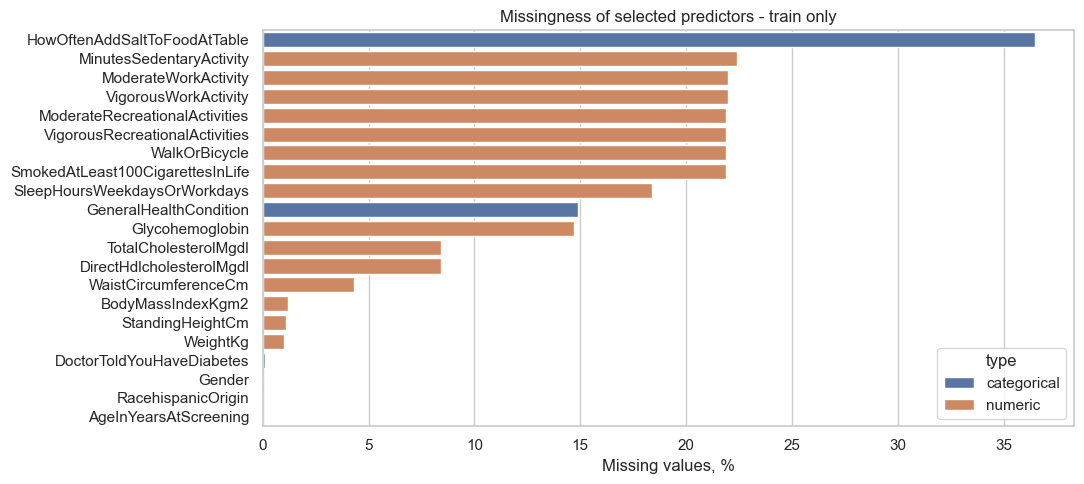

In [4]:
features = [
    'AgeInYearsAtScreening', 'Gender', 'RacehispanicOrigin',
    'BodyMassIndexKgm2', 'WeightKg', 'StandingHeightCm', 'WaistCircumferenceCm',
    'GeneralHealthCondition', 'DoctorToldYouHaveDiabetes',
    'SmokedAtLeast100CigarettesInLife', 'SleepHoursWeekdaysOrWorkdays',
    'HowOftenAddSaltToFoodAtTable',
    'VigorousWorkActivity', 'ModerateWorkActivity', 'WalkOrBicycle',
    'VigorousRecreationalActivities', 'ModerateRecreationalActivities',
    'MinutesSedentaryActivity', 'TotalCholesterolMgdl',
    'DirectHdlcholesterolMgdl', 'Glycohemoglobin'
]
assert not set(features).intersection({TARGET, 'SEQN', 'DiastolicBloodPressureMmHg'})

X_train, X_test = train_df[features].copy(), test_df[features].copy()
y_train, y_test = train_df[TARGET].copy(), test_df[TARGET].copy()
numeric_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = [feature for feature in features if feature not in numeric_features]

feature_overview = pd.DataFrame({'feature': features, 'type': ['numeric' if f in numeric_features else 'categorical' for f in features], 'missing_%': X_train[features].isna().mean().mul(100).round(1).values, 'unique_non_missing': X_train[features].nunique(dropna=True).values})
display(metadata.loc[metadata['VariableNameLong'].isin(features), ['VariableNameLong', 'VariableName', 'Label', 'Target', 'CustomRecoding']])
display(feature_overview)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=feature_overview.sort_values('missing_%', ascending=False), x='missing_%', y='feature', hue='type', dodge=False, ax=ax)
ax.set(title='Missingness of selected predictors - train only', xlabel='Missing values, %', ylabel='')
plt.tight_layout()
plt.show()

## 5. Разделение данных, предобработка и выбор модели

Тест уже отделен до EDA. Выбор модели проводится по минимальному среднему RMSE пятикратной CV на train. Для каждого фолда дополнительно проверяю отсутствие пересечения SEQN. Стандартное отклонение RMSE по пяти фолдам описывает разброс ошибок, но не является доверительным интервалом.

Ориентиры - медианный прогноз и Ridge-регрессия с L2-штрафом, уменьшающим величины коэффициентов при коррелирующих признаках. Основной кандидат - ExtraTreesRegressor, ансамбль рандомизированных деревьев. В узле рассматриваются случайные признаки и пороги; выбирается кандидат с наибольшим уменьшением среднеквадратичного разброса цели. Деление повторяется до условий остановки, прогноз листа - среднее обучающих целей в нем. Итог - среднее прогнозов 300 деревьев. При bootstrap=False каждое дерево использует весь обучающий фолд; разнообразие дают случайные признаки и пороги. Ансамбль учитывает нелинейности и взаимодействия, но сглаживает редкие крайние значения и плохо экстраполирует за обучающий диапазон.

Гиперпараметры заданы до итоговой оценки: 300 деревьев стабилизируют усреднение, min_samples_leaf=4 сдерживает слишком глубокие листья, max_features=0.8 поддерживает разнообразие деревьев. Extra Trees выбирается только если улучшает CV-ошибку относительно ориентиров.

In [5]:
assert X_train.index.intersection(X_test.index).empty
print(f'Train: {X_train.shape[0]:,} rows; test: {X_test.shape[0]:,} rows')

numeric_linear = Pipeline([('imputer', SimpleImputer(strategy='median', add_indicator=True)), ('scaler', StandardScaler())])
numeric_tree = SimpleImputer(strategy='median', add_indicator=True)
categorical = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('one_hot', OneHotEncoder(handle_unknown='ignore'))])

linear_preprocessor = ColumnTransformer([('num', numeric_linear, numeric_features), ('cat', categorical, categorical_features)])
tree_preprocessor = ColumnTransformer([('num', numeric_tree, numeric_features), ('cat', categorical, categorical_features)])

candidates = {
    'Median baseline': DummyRegressor(strategy='median'),
    'Ridge': Pipeline([('preprocess', linear_preprocessor), ('model', Ridge(alpha=10.0))]),
    'Extra Trees': Pipeline([('preprocess', tree_preprocessor), ('model', ExtraTreesRegressor(n_estimators=300, min_samples_leaf=4, max_features=0.8, random_state=RANDOM_STATE, n_jobs=-1))]),
}

cv = list(KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X_train))
for train_idx, valid_idx in cv:
    assert X_train.index[train_idx].intersection(X_train.index[valid_idx]).empty
print('All 5 CV folds: participant overlap = 0')
scoring = {'RMSE': 'neg_root_mean_squared_error', 'MAE': 'neg_mean_absolute_error', 'R2': 'r2'}
cv_rows = []
for name, estimator in candidates.items():
    scores = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_rows.append({'model': name, 'CV RMSE, mm Hg': -scores['test_RMSE'].mean(), 'CV MAE, mm Hg': -scores['test_MAE'].mean(), 'CV R2': scores['test_R2'].mean(), 'CV RMSE SD': scores['test_RMSE'].std()})

cv_results = pd.DataFrame(cv_rows).sort_values('CV RMSE, mm Hg').reset_index(drop=True)
display(cv_results.round(3))
selected_name = cv_results.loc[0, 'model']
print(f'Selected from training-only CV: {selected_name}')

Train: 5,371 rows; test: 1,343 rows
All 5 CV folds: participant overlap = 0


,model,"CV RMSE, mm Hg","CV MAE, mm Hg",CV R2,CV RMSE SD
0,Extra Trees,15.498,11.297,0.418,0.322
1,Ridge,15.596,11.486,0.411,0.424
2,Median baseline,20.688,15.470,-0.036,0.722


Selected from training-only CV: Extra Trees


## 6. Оценка на отложенных участниках

Модель с минимальным CV RMSE обучается на всей train-части; ниже выполняется финальная оценка. MAE - средняя абсолютная ошибка в мм рт. ст.; RMSE сильнее штрафует крупные ошибки; R² = 1 - SSE/SST относительно тестового среднего и может быть отрицательным. Метрики не измеряют причинность.

История проверки: в первой версии были оценены строки с повторяющимися участниками. При аудите обнаружены дубли и неочищенный PAD680; эта версия исправляет методику и пересчитывает результат. Прежние метрики считать корректной оценкой нельзя. Исправленный holdout не является полностью новым внешним набором: часть наблюдений уже встречалась в предыдущем анализе. Признаки и гиперпараметры не подбирались по исправленному тесту. Для независимого подтверждения нужен другой набор участников/цикл NHANES.

,model,"test MAE, mm Hg","test RMSE, mm Hg",test R2
0,Extra Trees,11.403,15.57,0.416


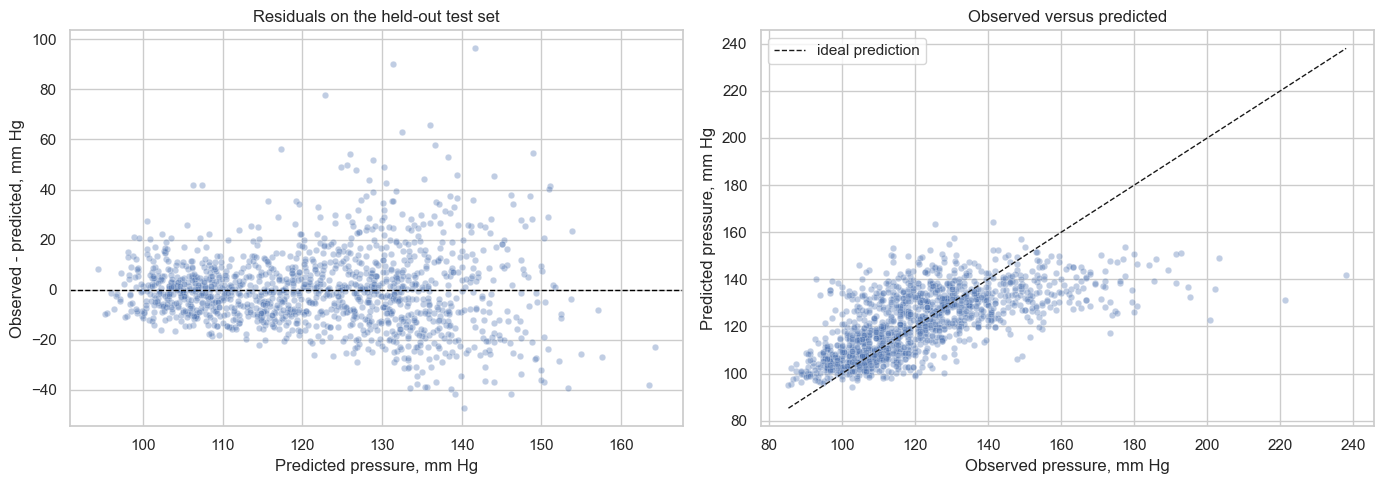

In [6]:
final_model = candidates[selected_name]
final_model.fit(X_train, y_train)
test_prediction = final_model.predict(X_test)

test_metrics = pd.DataFrame([{'model': selected_name, 'test MAE, mm Hg': mean_absolute_error(y_test, test_prediction), 'test RMSE, mm Hg': mean_squared_error(y_test, test_prediction) ** 0.5, 'test R2': r2_score(y_test, test_prediction)}])
display(test_metrics.round(3))

residuals = y_test - test_prediction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=test_prediction, y=residuals, alpha=.35, s=22, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set(title='Residuals on the held-out test set', xlabel='Predicted pressure, mm Hg', ylabel='Observed - predicted, mm Hg')

sns.scatterplot(x=y_test, y=test_prediction, alpha=.35, s=22, ax=axes[1])
limits = [min(y_test.min(), test_prediction.min()), max(y_test.max(), test_prediction.max())]
axes[1].plot(limits, limits, 'k--', linewidth=1, label='ideal prediction')
axes[1].set(title='Observed versus predicted', xlabel='Observed pressure, mm Hg', ylabel='Predicted pressure, mm Hg')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Интерпретация и ограничения

Для выбранного ансамбля приведена impurity-based importance признаков после предобработки. Она показывает, какие преобразованные признаки чаще уменьшали разброс цели в деревьях. Это не причинная интерпретация и может распределять важность между коррелирующими показателями, например весом, ИМТ и окружностью талии.

Ограничения решения: NHANES здесь используется как поперечная выборка без учёта survey weights; часть входов самоотчётная и имеет пропуски; возраст 80 и выше закодирован как 80; измерение давления вариабельно даже при повторных измерениях. Поэтому модель - воспроизводимый прогнозный пример, но не клинический инструмент и не основание для медицинских решений.

,transformed_feature,importance
0,num__AgeInYearsAtScreening,0.4024
22,num__missingindicator_VigorousWorkActivity,0.1033
2,num__WeightKg,0.0361
4,num__WaistCircumferenceCm,0.0289
1,num__BodyMassIndexKgm2,0.0234
34,cat__RacehispanicOrigin_Non-Hispanic Black,0.0224
3,num__StandingHeightCm,0.0216
13,num__TotalCholesterolMgdl,0.0206
14,num__DirectHdlcholesterolMgdl,0.0177
5,num__SmokedAtLeast100CigarettesInLife,0.0165


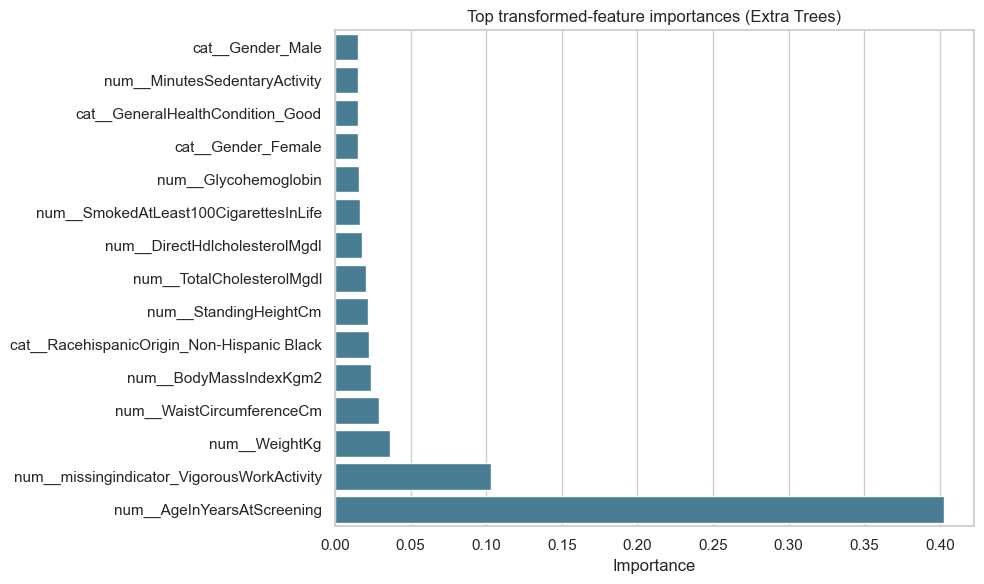

**Вывод.** По CV выбрана модель **Extra Trees**. На 1343 отложенных участниках: **MAE = 11.40 мм рт. ст.**, **RMSE = 15.57 мм рт. ст.**, **R² = 0.416**. Участники train/test и обучающих/валидационных фолдов не пересекаются. Это внутренняя оценка после исправления методики, не независимая внешняя валидация.

In [7]:
if selected_name == 'Extra Trees':
    transformed_names = final_model.named_steps['preprocess'].get_feature_names_out()
    importances = pd.DataFrame({'transformed_feature': transformed_names, 'importance': final_model.named_steps['model'].feature_importances_}).sort_values('importance', ascending=False)
    display(importances.head(15).round(4))

    fig, ax = plt.subplots(figsize=(10, 6))
    top = importances.head(15).sort_values('importance')
    sns.barplot(data=top, x='importance', y='transformed_feature', color='#3B82A0', ax=ax)
    ax.set(title='Top transformed-feature importances (Extra Trees)', xlabel='Importance', ylabel='')
    plt.tight_layout()
    plt.show()
else:
    print('The selected model is not tree-based; no tree feature importances are reported.')

display(Markdown(f'''**Вывод.** По CV выбрана модель **{selected_name}**. На {len(y_test)} отложенных участниках: **MAE = {test_metrics.loc[0, 'test MAE, mm Hg']:.2f} мм рт. ст.**, **RMSE = {test_metrics.loc[0, 'test RMSE, mm Hg']:.2f} мм рт. ст.**, **R² = {test_metrics.loc[0, 'test R2']:.3f}**. Участники train/test и обучающих/валидационных фолдов не пересекаются. Это внутренняя оценка после исправления методики, не независимая внешняя валидация.'''))

## Воспроизводимость

Из корня репозитория (Python 3.13.12):

```bash
python3.13 -m venv .venv
source .venv/bin/activate
python -m pip install -r ML/requirements.txt
python -m ipykernel install --prefix .venv --name bioinf-iii --display-name 'BIOINF III'
python -m jupyterlab
```

Откройте ML/blood_pressure_regression.ipynb, выберите ядро BIOINF III и Restart Kernel and Run All Cells. CSV версионируются; загрузка данных из интернета при выполнении не нужна. Версии выводятся в начале, seed=42 фиксирован. Все семь кодовых ячеек должны завершиться без ошибок. Исходные CSV не меняются. Порядок очистки и разбиения фиксирован; параметры моделей сохранены из первоначальной версии.